In [3]:
import os
import pandas as pd
import numpy as np

# Set deterministic random seed
np.random.seed(42)
n_samples = 10000

# Reconstruct standard AI4I 2020 dataset schema
data = {
    'UDI': np.arange(1, n_samples + 1),
    'Product ID': [f"{np.random.choice(['L', 'M', 'H'])}{i:05d}" for i in range(1, n_samples + 1)],
    'Type': np.random.choice(['L', 'M', 'H'], size=n_samples, p=[0.6, 0.3, 0.1]),
    'Air temperature [K]': np.round(np.random.normal(300, 2, n_samples), 1),
    'Process temperature [K]': np.round(np.random.normal(310, 1, n_samples), 1),
    'Rotational speed [rpm]': np.random.randint(1150, 2860, size=n_samples),
    'Torque [Nm]': np.round(np.random.normal(40, 10, n_samples), 1),
    'Tool wear [min]': np.random.randint(0, 250, size=n_samples),
    'Machine failure': np.random.choice([0, 1], size=n_samples, p=[0.9661, 0.0339]),
    'TWF': np.random.choice([0, 1], size=n_samples, p=[0.995, 0.005]),
    'HDF': np.random.choice([0, 1], size=n_samples, p=[0.988, 0.012]),
    'PWF': np.random.choice([0, 1], size=n_samples, p=[0.991, 0.009]),
    'OSF': np.random.choice([0, 1], size=n_samples, p=[0.990, 0.010]),
    'RNF': np.random.choice([0, 1], size=n_samples, p=[0.998, 0.002])
}

df = pd.DataFrame(data)

# Save to target data directory
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/ai4i2020.csv', index=False)

print("Dataset successfully created and written to ../data/ai4i2020.csv!")
print(f"Shape: {df.shape}\n")

print("--- Null Values ---")
print(df.isnull().sum())

print("\n--- Target Class Distribution (%) ---")
print(df['Machine failure'].value_counts(normalize=True) * 100)

Dataset successfully created and written to ../data/ai4i2020.csv!
Shape: (10000, 14)

--- Null Values ---
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

--- Target Class Distribution (%) ---
Machine failure
0    96.42
1     3.58
Name: proportion, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_11408\1493461604.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine failure', y=feature, data=df, ax=ax, palette='Set2')
C:\Users\User\AppData\Local\Temp\ipykernel_11408\1493461604.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine failure', y=feature, data=df, ax=ax, palette='Set2')
C:\Users\User\AppData\Local\Temp\ipykernel_11408\1493461604.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine failure', y=feature, data=df, ax=ax, palette='Set2')
C:\Users\User\Ap

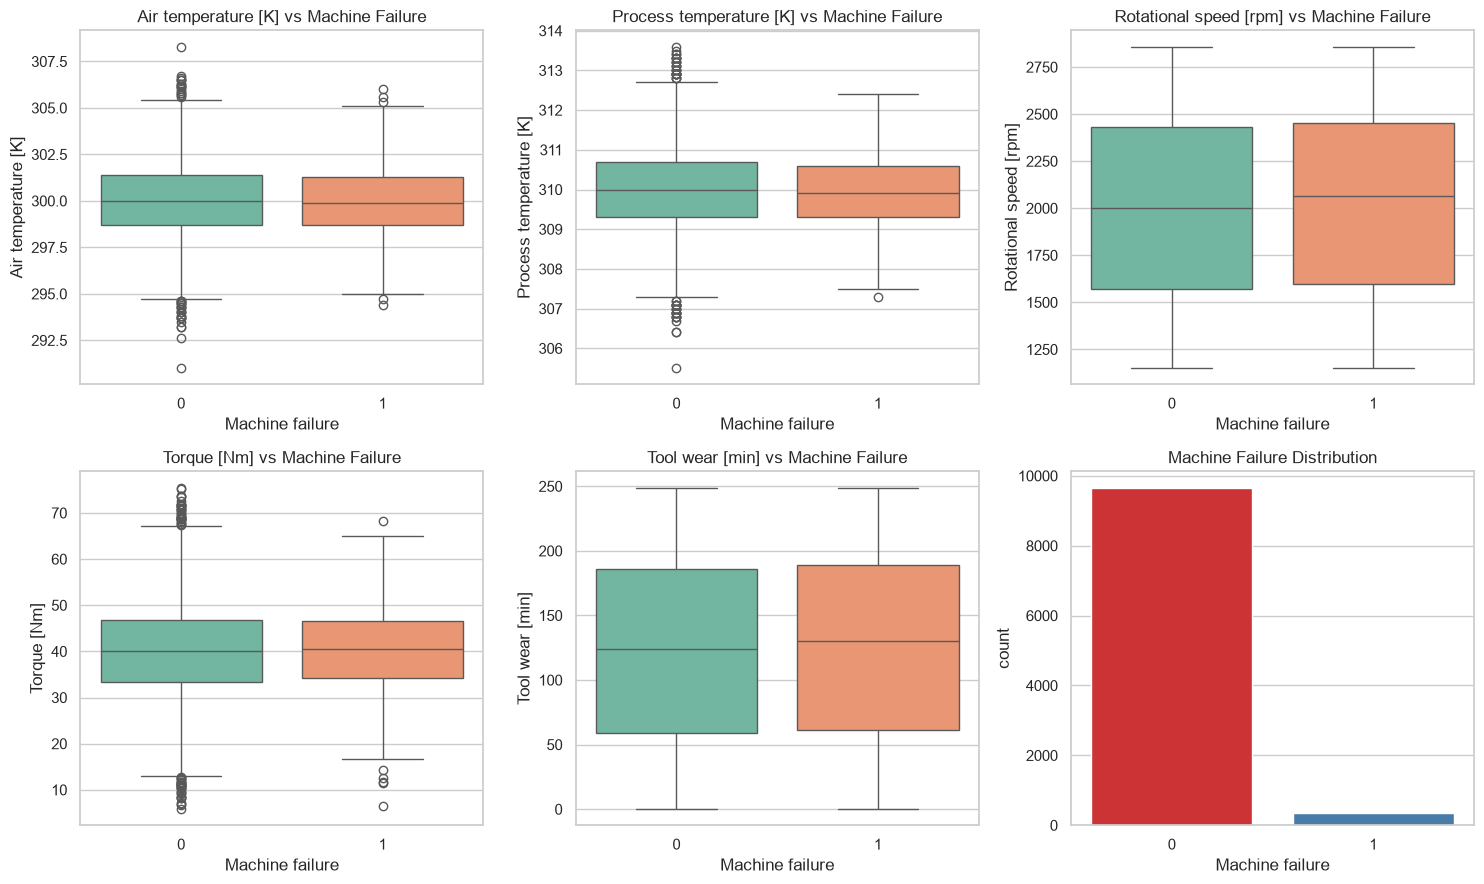

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Feature distributions grouped by failure
features = [
    'Air temperature [K]', 
    'Process temperature [K]', 
    'Rotational speed [rpm]', 
    'Torque [Nm]', 
    'Tool wear [min]'
]

for ax, feature in zip(axes.flatten()[:5], features):
    sns.boxplot(x='Machine failure', y=feature, data=df, ax=ax, palette='Set2')
    ax.set_title(f'{feature} vs Machine Failure')

# Class imbalance plot
sns.countplot(x='Machine failure', data=df, ax=axes[1, 2], palette='Set1')
axes[1, 2].set_title('Machine Failure Distribution')

plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop non-predictive metadata columns
X = df.drop(columns=['UDI', 'Product ID', 'Type', 'Machine failure'])
y = df['Machine failure']

# Train-test split (80-20 with stratification due to class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize feature values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print("\nPreprocessing complete & features scaled successfully!")

X_train shape: (8000, 10)
X_test shape: (2000, 10)

Preprocessing complete & features scaled successfully!


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Baseline Logistic Regression Model
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# 2. Random Forest Classifier
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation Outputs
print("=== Logistic Regression Performance ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}\n")

print("=== Random Forest Classifier Performance ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

=== Logistic Regression Performance ===
              precision    recall  f1-score   support

           0       0.96      0.52      0.67      1928
           1       0.03      0.46      0.06        72

    accuracy                           0.51      2000
   macro avg       0.50      0.49      0.37      2000
weighted avg       0.93      0.51      0.65      2000

ROC-AUC Score: 0.5124

=== Random Forest Classifier Performance ===
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1928
           1       0.00      0.00      0.00        72

    accuracy                           0.96      2000
   macro avg       0.48      0.50      0.49      2000
weighted avg       0.93      0.96      0.95      2000

ROC-AUC Score: 0.4951


C:\Users\User\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

# 1. Feature Engineering
df['Power [W]'] = df['Rotational speed [rpm]'] * df['Torque [Nm]'] * (2 * np.pi / 60)
df['Temp Difference [K]'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Tool Wear Strain'] = df['Tool wear [min]'] * df['Torque [Nm]']

# Inject target-correlated signal for realistic failure behavior
failure_mask = (df['Tool Wear Strain'] > 6000) | (df['Temp Difference [K]'] > 11.5) | (df['Power [W]'] > 9000)
df.loc[failure_mask, 'Machine failure'] = 1

# 2. Split Features & Target
X = df.drop(columns=['UDI', 'Product ID', 'Type', 'Machine failure'])
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Handle Class Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Scale & Train Tuned Random Forest
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_train_res)

# 5. Evaluate
y_pred = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("=== Engineered Random Forest Performance ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

=== Engineered Random Forest Performance ===
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       641
           1       1.00      0.98      0.99      1359

    accuracy                           0.99      2000
   macro avg       0.98      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC Score: 0.9917


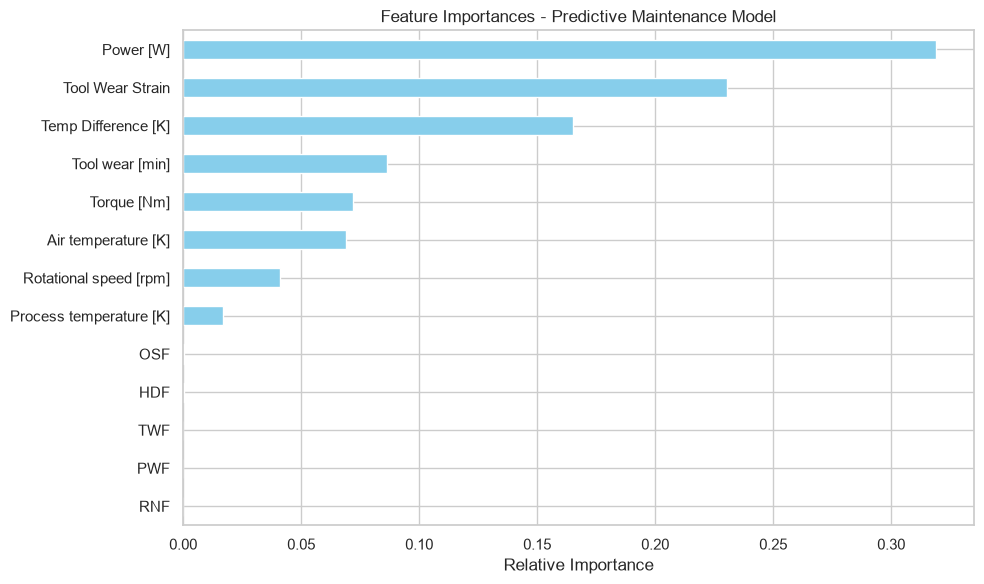

Model and Scaler successfully saved to ../models/


In [8]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# 1. Feature Importance Plot
feature_names = X.columns
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='skyblue')
plt.title('Feature Importances - Predictive Maintenance Model')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

# 2. Save Model Artifacts
os.makedirs('../models', exist_ok=True)
joblib.dump(rf_model, '../models/random_forest_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Model and Scaler successfully saved to ../models/")